<a href="https://colab.research.google.com/github/masaki-kawa/uts-study-notes/blob/main/data/raw/colab/Deep_Learning_Lab5_Exercise1_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Weather Temperatures using RNN
### *Weather Dataset*

----------------------------------------------

# Predicting the weather temperatures

## Dataset

Forecasting weather temperatures has been a challenging yet vital task in meteorology. Effective temperature prediction models aid in various sectors, including agriculture, tourism, and public safety. The dataset used in this exercise contains historical temperature data.

`Link to the dataset: `https://www.kaggle.com/datasets/swatikhedekar/python-project-on-weather-dataset


## Objective

Our goal is to employ a Recurrent Neural Network (RNN) to predict future temperatures based on historical data. RNNs are particularly suited for this task due to their ability to remember previous inputs.

## Instructions

In this exercise, we delve into applying a basic Recurrent Neural Network (RNN) on time series data to predict weather temperatures.

The exercise is divided into several parts:

1. **Loading and Exploration of the Dataset**: Understand the structure of the data.
2. **Preparing the Dataset**: Process the data for the RNN model, including normalization, creating sequences, and splitting into training, validation, and test sets.
3. **Defining the Architecture of the RNN**: Outline and implement the structure of the RNN model suitable for temperature prediction.
4. **Training and Evaluation of the RNN Model**: Focus on training the model with the prepared dataset and evaluating its performance using suitable metrics.
5. **Analysing the Results**: Interpret the model's predictions, analyze its performance, and explore potential areas for improvement.


## Exercise 1

### 1. Loading and Exploration of the Dataset

**[1.1]** First we need to import the relevant Pytorch and Python libraries

In [ ]:
# Solution
# Library for numerical computations and working with arrays.
import numpy as np

# Data manipulation and analysis library, ideal for working with tabular data.
import pandas as pd

# Library for creating visualizations in Python.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Preprocessing module from Scikit-learn, specifically for scaling features to a range.
from sklearn.preprocessing import MinMaxScaler

# Core PyTorch libraries for tensor computations, neural network basics, and common functions.
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Optimizers for training the model.
from torch.optim import Adam, SGD  # You can add more optimizers as needed

# Libraries for evaluating model performance.
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# Additional PyTorch modules for regularization techniques
from torch.nn.utils import clip_grad_norm_  # For gradient clipping

**[1.2]** Now we will choose the device type [CPU/GPU] in such a way that if GPU is available then use GPU otherwise use CPU.

In [ ]:
# Solution
# Check if GPU is available and set PyTorch to use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


**[1.3]** Let's Load the data and returns the top 5 rows.

In [ ]:
url = "https://drive.google.com/uc?export=download&id=12_rnY16-4ez0iV4HCtgPFTJbQ-zIGjES"
data = pd.read_csv(url)
data

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...,...
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow


**[1.4]** Let's have a look at the shape of the data

In [ ]:
# Solution
data.shape

(8784, 8)

**[1.5]** Let's check if we have any null values in the data

In [ ]:
# Solution
data.isnull().sum()

,0
Date/Time,0
Temp_C,0
Dew Point Temp_C,0
Rel Hum_%,0
Wind Speed_km/h,0
Visibility_km,0
Press_kPa,0
Weather,0


**[1.6]** Let's print out the name of the columns

In [ ]:
# Solution
data.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

**[1.7]** Now we will print the datatype of each column

In [ ]:
# Solution
# Print data types of each column
print("Data types of each column:")
print(data.dtypes)

Data types of each column:
Date/Time            object
Temp_C              float64
Dew Point Temp_C    float64
Rel Hum_%             int64
Wind Speed_km/h       int64
Visibility_km       float64
Press_kPa           float64
Weather              object
dtype: object


# 2. Preparing the Dataset


**[2.1]** Let's change the name of the columns for better readability

In [ ]:
# Solution
data.columns = ['date', 'temperature', 'dew_point', 'rel_humidity', 'wind_speed', 'visibility', 'pressure', 'weather']
data.columns

Index(['date', 'temperature', 'dew_point', 'rel_humidity', 'wind_speed',
       'visibility', 'pressure', 'weather'],
      dtype='object')

**[2.2]** Now we will convert the `date` column into datetype. For time series analysis it is a better practice to convert the datatype of the dates if that is string/object by default. We will also use that date as an index here so that we can use that later on without any modification.

In [ ]:
# Solution
# Convert 'date' column to datetime format
data['date'] = pd.to_datetime(data['date'])

# Set 'date' column as index
data.set_index('date', inplace=True)

# Display the first few rows to verify the changes
data.head(5)

,temperature,dew_point,rel_humidity,wind_speed,visibility,pressure,weather
date,,,,,,,
2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


**[2.3]** Let's have a deeper look at the categorical column `weather`.

In [ ]:
# Solution
print(f"Number of Distinct Weather Values: {data['weather'].nunique()}")
print("\n")
print(f"Distinct Weather Values: {data['weather'].unique()}")

Number of Distinct Weather Values: 50


Distinct Weather Values: ['Fog' 'Freezing Drizzle,Fog' 'Mostly Cloudy' 'Cloudy' 'Rain'
 'Rain Showers' 'Mainly Clear' 'Snow Showers' 'Snow' 'Clear'
 'Freezing Rain,Fog' 'Freezing Rain' 'Freezing Drizzle' 'Rain,Snow'
 'Moderate Snow' 'Freezing Drizzle,Snow' 'Freezing Rain,Snow Grains'
 'Snow,Blowing Snow' 'Freezing Fog' 'Haze' 'Rain,Fog' 'Drizzle,Fog'
 'Drizzle' 'Freezing Drizzle,Haze' 'Freezing Rain,Haze' 'Snow,Haze'
 'Snow,Fog' 'Snow,Ice Pellets' 'Rain,Haze' 'Thunderstorms,Rain'
 'Thunderstorms,Rain Showers' 'Thunderstorms,Heavy Rain Showers'
 'Thunderstorms,Rain Showers,Fog' 'Thunderstorms' 'Thunderstorms,Rain,Fog'
 'Thunderstorms,Moderate Rain Showers,Fog' 'Rain Showers,Fog'
 'Rain Showers,Snow Showers' 'Snow Pellets' 'Rain,Snow,Fog'
 'Moderate Rain,Fog' 'Freezing Rain,Ice Pellets,Fog'
 'Drizzle,Ice Pellets,Fog' 'Drizzle,Snow' 'Rain,Ice Pellets'
 'Drizzle,Snow,Fog' 'Rain,Snow Grains' 'Rain,Snow,Ice Pellets'
 'Snow Showers,Fog' 'Moderate Snow,B

**[2.4]** Now we will get the distinct weather values for the categorical column `weather` and convert the into a neumeric one.

In [ ]:
# Solution
# Get the distince weather values
distinct_weather = data['weather'].unique()

# Create a mapping dictionary
weather_mapping = {weather: idx for idx, weather in enumerate(distinct_weather)}
weather_mapping

{'Fog': 0,
 'Freezing Drizzle,Fog': 1,
 'Mostly Cloudy': 2,
 'Cloudy': 3,
 'Rain': 4,
 'Rain Showers': 5,
 'Mainly Clear': 6,
 'Snow Showers': 7,
 'Snow': 8,
 'Clear': 9,
 'Freezing Rain,Fog': 10,
 'Freezing Rain': 11,
 'Freezing Drizzle': 12,
 'Rain,Snow': 13,
 'Moderate Snow': 14,
 'Freezing Drizzle,Snow': 15,
 'Freezing Rain,Snow Grains': 16,
 'Snow,Blowing Snow': 17,
 'Freezing Fog': 18,
 'Haze': 19,
 'Rain,Fog': 20,
 'Drizzle,Fog': 21,
 'Drizzle': 22,
 'Freezing Drizzle,Haze': 23,
 'Freezing Rain,Haze': 24,
 'Snow,Haze': 25,
 'Snow,Fog': 26,
 'Snow,Ice Pellets': 27,
 'Rain,Haze': 28,
 'Thunderstorms,Rain': 29,
 'Thunderstorms,Rain Showers': 30,
 'Thunderstorms,Heavy Rain Showers': 31,
 'Thunderstorms,Rain Showers,Fog': 32,
 'Thunderstorms': 33,
 'Thunderstorms,Rain,Fog': 34,
 'Thunderstorms,Moderate Rain Showers,Fog': 35,
 'Rain Showers,Fog': 36,
 'Rain Showers,Snow Showers': 37,
 'Snow Pellets': 38,
 'Rain,Snow,Fog': 39,
 'Moderate Rain,Fog': 40,
 'Freezing Rain,Ice Pellets,Fog':

**[2.5]** Save the numerical value (i.e. mapping) to the categorical column `data[weather]`.

In [ ]:
# Solution
# Get the numeric values instead of categorical values from weather
data['weather'] = data['weather'].map(weather_mapping)
data.head(5)

,temperature,dew_point,rel_humidity,wind_speed,visibility,pressure,weather
date,,,,,,,
2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,0
2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,0
2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,1
2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,1
2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,0


**[2.6]** Test that the `weather` column is changed.

In [ ]:
# Solution
print(f"Number of Distinct Weather Values: {data['weather'].nunique()}")
print("\n")
print(f"Distinct Weather Values: {data['weather'].unique()}")

Number of Distinct Weather Values: 50


Distinct Weather Values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


**[2.7]** Let's visualize the temperature over time

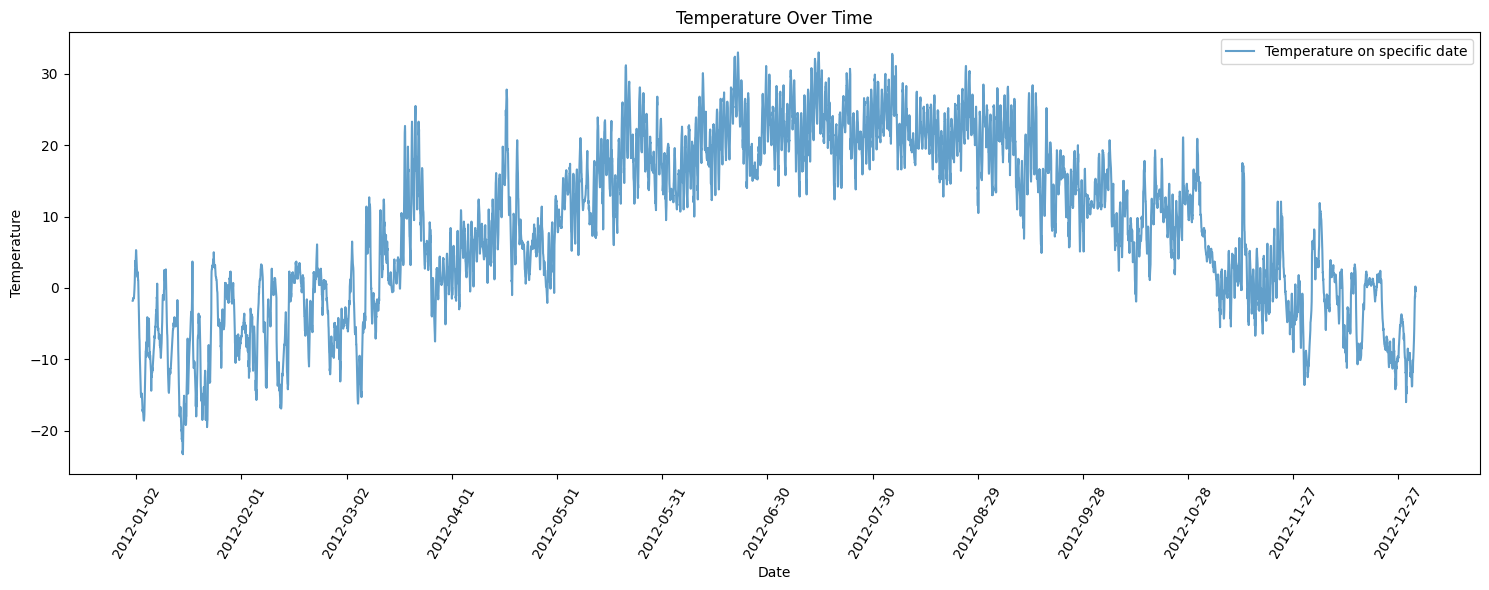

In [ ]:
# Solution
plt.figure(figsize=(15, 6))
plt.plot(data.index, data['temperature'], label='Temperature on specific date', alpha=0.7)

# The data is too crowded. So, we will use interval in dates
n = 30  # Example: Show a tick every 30 days.
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=n))

plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Temperature Over Time')
plt.legend()

plt.xticks(rotation=60)  # Rotate date labels for better readability
plt.tight_layout()

plt.show()

**[2.8]** Let's check if the data is in chronological order. This is a crucial requirement for Time Series Data.

In [ ]:
# Solution
print("Is my dataset ordered Chronologically?")
print(f"Answer: {data.index.is_monotonic_increasing}")

Is my dataset ordered Chronologically?
Answer: True


**[2.9]** Lookback

Generate new columns for each day in the lookback period, showing the 'temperature' of last 24 hours of previous days. This transformation essentially provides historical context needed to predict the future values.
Set the loopback = 24.

In [ ]:
# Solution
lookback_size = 24 # for each our of the day

# Generate new columns for each hour of previous day, showing the 'temperature' 'lookback_size' hours ago.
shifted_columns = {f'temperature(t-{i})': data['temperature'].shift(i) for i in range(1, lookback_size + 1)}
# Add the new columns to the DataFrame.
data_shifted = data.assign(**shifted_columns)

# Remove any rows that contain NaN values, which occur at the start of the DataFrame due to shifting.
data_shifted.dropna(inplace=True)
data_shifted.head(3)

,temperature,dew_point,rel_humidity,wind_speed,visibility,pressure,weather,temperature(t-1),temperature(t-2),temperature(t-3),...,temperature(t-15),temperature(t-16),temperature(t-17),temperature(t-18),temperature(t-19),temperature(t-20),temperature(t-21),temperature(t-22),temperature(t-23),temperature(t-24)
date,,,,,,,,,,,,,,,,,,,,,
2012-01-02 00:00:00,5.2,1.5,77,35,25.0,99.26,5,5.3,4.4,4.0,...,-1.3,-1.4,-1.4,-1.5,-1.4,-1.5,-1.5,-1.8,-1.8,-1.8
2012-01-02 01:00:00,4.6,0.0,72,39,25.0,99.26,3,5.2,5.3,4.4,...,-1.0,-1.3,-1.4,-1.4,-1.5,-1.4,-1.5,-1.5,-1.8,-1.8
2012-01-02 02:00:00,3.9,-0.9,71,32,25.0,99.26,2,4.6,5.2,5.3,...,-0.5,-1.0,-1.3,-1.4,-1.4,-1.5,-1.4,-1.5,-1.5,-1.8


**[2.9]** Now, we will split the size of new data set called `data_shifted` (after applying loopback on the original dataset named `data`) for the train-test-validation. It follows the following ratio: 70-15-15.

In [ ]:
# Solution
# Calculate the indices for splitting
train_size = int(data_shifted.shape[0] * 0.7)
validation_size = int(data_shifted.shape[0] * 0.15)
test_size = data_shifted.shape[0] - train_size - validation_size
print(train_size)
print(validation_size)
print(test_size)

6132
1314
1314


**[2.10]** Let's split the data based on the above sizes and save the data into `train_df`, `validation_df`, and `test_df`. For indexing we are using the iloc function of pandas (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html).

In [ ]:
# Solution
# Split the data by indices
train_df = data_shifted.iloc[:train_size, :]
validation_df = data_shifted.iloc[train_size:train_size+validation_size, :]
test_df = data_shifted.iloc[train_size+validation_size:, :]

**[2.11]** Let's normalize the data i.e. scaling features to a given range (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html).

In [ ]:
# Solution
# Initialize the MinMaxScaler to scale the features to a range between 0 and 1.
scaler = MinMaxScaler(feature_range=(0, 1))

# Since 'Date' is already the index, all columns in the DataFrame can be normalized without explicit exclusion.
# Normalize the training data by fitting the scaler to the training DataFrame and transforming it.
train_df[:] = scaler.fit_transform(train_df)

# Normalize the validation and test data using the scaler fitted on the training data.
# This ensures that all datasets are scaled similarly.
validation_df[:] = scaler.transform(validation_df)
test_df[:] = scaler.transform(test_df)

/tmp/ipykernel_5220/3365310854.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[:] = scaler.fit_transform(train_df)
/tmp/ipykernel_5220/3365310854.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.7195122  0.65853659 0.64634146 ... 0.52439024 0.5        0.43902439]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df[:] = scaler.fit_transform(train_df)
/tmp/ipykernel_5220/3365310854.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.42168675 0.46987952 0.38554217 ... 0.15662651 0.20481928 0.18072289]' has dtype incompatible with int64, ple

# 3. Create the Sequence

**[3.1]** To prepare the dataset for weather forecasting, we need to frame it as a time series problem. To predict the next day's temperature, we will use the previous 24 hours' temperature. Let's define a function called `create_sequences` having the following parameters: data, seq_length and target_index value (for this dataset, the target column name is temperature and the index is 0).

In [ ]:
# Solution
def create_sequences(data, seq_length, target_index = 0):
    """
    Prepares time series data for RNN by creating overlapping sequences of a specified length.

    Args:
    - data: DataFrame with each column representing a time step's feature value.
    - seq_length: The number of time steps to include in each input sequence, defining the temporal context for predictions.

    Returns:
    - xs: An array of input sequences, each sequence providing the RNN with a window of historical data.
    - ys: An array of target values, each corresponding to the temperature immediately following a sequence.
    """
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        # Extract the sequence of length 'seq_length' starting at index 'i', excluding the 'temperature' value.
        x = np.delete(data[i:(i + seq_length), :], target_index, axis=1) # Exclude 'temperature' Values from the training data. by default it is 0 as the 1st column in the data is 'temperature'
        y = data[i + seq_length, target_index] # Take 'temperature' as the label
        xs.append(x) # Append the sequence to the input list.
        ys.append(y) # # Append the target value to the target list.
    return np.array(xs), np.array(ys) # Convert lists to numpy arrays and return them.

**[3.2]** Set the sequence length variable named `seq_length` to 24 and call the `create_sequences` function for train dataframe, validation dataframe and test dataframe.

In [ ]:
# Solution
seq_length = 24  # mimicing the hours of the day

# The index of 'temperature' column in your dataset
target_index = 0

# Create sequences for each set
# Convert the datasets into Numpy arrays before passing
X_train, y_train = create_sequences(train_df.values, seq_length, target_index)
X_val, y_val = create_sequences(validation_df.values, seq_length, target_index)
X_test, y_test = create_sequences(test_df.values, seq_length, target_index)

**[3.3]** Convert the `X_train`,`y_train`,`X_val`,`y_val`,`X_test` and `y_test` to PyTorch tensors.

In [ ]:
# Solution
# Convert to PyTorch tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float), torch.tensor(y_train, dtype=torch.float))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float), torch.tensor(y_val, dtype=torch.float))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float), torch.tensor(y_test, dtype=torch.float))

# 4. Define the architecture of RNN

**[4.1]** Let's create a RNN model named `class RNN`. This RNN model processes sequences of data, applying an RNN layer followed by batch normalization, dropout for regularization, and a fully connected layer to output predictions. The model focuses on the last timestep's output for its final prediction.

In [ ]:
# Solution
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=2, dropout_rate=0.2):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.batch_norm = nn.BatchNorm1d(num_features=hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_length, input_size)
        x, _ = self.rnn(x)
        # Select the output of the last time step
        x = x[:, -1, :]
        x = self.batch_norm(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

**[4.2]** Let's set the model parameters. For number of features, set the input_size=dynamically allocated, hidden_size = 64 and number of stacked RNN layers, num_layers = 2, dropout_rate = 0.4.

In [ ]:
# Solution
# Model parameters
input_size = X_train.shape[2]  # Number of features
hidden_size = 64  # Can be adjusted
num_layers = 2  # Number of RNN layers
dropout_rate = 0.4  # Dropout rate

**[4.3]** Let's instantiate the newly created RNN and save it to `model`

In [ ]:
# Solution
# Instantiate the model
model = RNN(input_size, hidden_size, num_layers=num_layers, dropout_rate=dropout_rate).to(device)

**[4.4]** Let's set the training parameters. For learning = 0.001, num_epoch = 30, loss_function = nn.MSELoss(), Optimizer to be Adam. We will also use weight_decay(l2 regularization) here to be 1e-5.

In [ ]:
# Solution
from torch.optim import Adam
# Training Parameters
learning_rate = 0.001
num_epochs = 30
loss_function = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

**[4.5]** Let's define the empty lists to store the training and validation outcomes

In [ ]:
# Solution
train_losses, val_losses = [], []
train_maes, val_maes = [], []
train_rmses, val_rmses = [], []

**[4.6]** Now we will call the DataLoader function that iteratively loads data based on batch size, shuffle and save it into three different variables called `train_loader`, `val_loader` and `test_loader`. Set the `BATCH_SIZE` to 64.

In [ ]:
# Solution
# Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

**[4.7]** Let's define a function called `train_one_epoch` that takes the following parameters model, device, train_loader, optimizer, loss_function and max_norm. This function is responsible to train our newly created RNN model.
A nested loop is initiated that extracts data from `train_loader` and introduce the following logics:
- reset the gradients (https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- perform back propagation
- update the weights
- Count the total loss

In [ ]:
# Solution
def train_one_epoch(model, device, train_loader, optimizer, loss_function, max_norm=2):
    """
    Trains the model for one epoch over the provided training data, with gradient clipping.

    Args:
    - model: The RNN model to be trained.
    - device: The device (CPU or GPU) to perform training on.
    - train_loader: DataLoader for the training dataset, providing batches of (input, target) pairs.
    - optimizer: The optimization algorithm used to update model weights.
    - loss_function: The loss function used to compute the discrepancy between model predictions and actual targets.
    - max_norm: The maximum norm for the gradients; gradients will be normalized if their norm exceeds this value.

    Returns:
    - avg_loss: The average loss over all batches in this epoch.
    - mae: The Mean Absolute Error of model predictions against actual targets over all batches.
    - rmse: The Root Mean Squared Error of model predictions against actual targets over all batches.
    """
    model.train()  # Set the model to training mode
    running_loss = 0.0
    all_actuals = []
    all_predictions = []

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_batch)
        loss = loss_function(outputs.view(-1), y_batch)

        loss.backward()

        # Gradient clipping
        clip_grad_norm_(model.parameters(), max_norm=max_norm)

        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
        all_actuals.extend(y_batch.tolist())
        all_predictions.extend(outputs.detach().cpu().view(-1).tolist())

    avg_loss = running_loss / len(train_loader.dataset)
    mae = mean_absolute_error(all_actuals, all_predictions)
    rmse = math.sqrt(mean_squared_error(all_actuals, all_predictions))

    return avg_loss, mae, rmse


**[4.8]** To validate the model a nested loop is initiated that extracts data from `val_loader` and introduce the following logics:
- disable computing gradients (https://pytorch.org/docs/stable/generated/torch.no_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- Count the total loss
- Count the correct outcome

In [ ]:
# Solution
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def validate(model, device, loader, loss_function):
    """
    Validates the model's performance on a given dataset.

    Args:
    - model: The RNN model being evaluated. Applicable to any model that outputs a single prediction per sequence.
    - device: The computational device (CPU or GPU) to use.
    - loader: DataLoader providing batches of validation/test data.
    - loss_function: The loss function used to compute the discrepancy between predictions and targets.

    Returns:
    - avg_loss: The average loss over all batches in the validation/test dataset.
    - mae: Mean Absolute Error of predictions against actual targets over the entire dataset.
    - rmse: Root Mean Squared Error of predictions against actual targets over the entire dataset.
    """
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    all_actuals = []
    all_predictions = []

    with torch.no_grad():  # Disable gradient computation
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            # Ensure the outputs have the correct shape for loss calculation
            loss = loss_function(outputs.view(-1), y_batch)
            running_loss += loss.item()

            # Collect data for MAE and RMSE calculations
            all_actuals.extend(y_batch.cpu().numpy().flatten().tolist())
            all_predictions.extend(outputs.cpu().view(-1).numpy().flatten().tolist())

    avg_loss = running_loss / len(loader)
    mae = mean_absolute_error(all_actuals, all_predictions)
    rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))

    return avg_loss, mae, rmse

**[4.9]** **Training:** Now it is time to train our model by calling train_one_epoch and validate functions. The evaluation metrics are stored in train_losses, val_losses, train_maes, val_maes, train_rmses, val_rmses by using append function.

In [ ]:
# Solution
# Training loop with validation
for epoch in range(num_epochs):
    # Perform training for one epoch and compute metrics
    train_loss, train_mae, train_rmse = train_one_epoch(model, device, train_loader, optimizer, loss_function)

    # Validate the model's performance on the validation dataset and compute metrics
    val_loss, val_mae, val_rmse = validate(model, device, val_loader, loss_function)

    # Save the metrics for further analysis or monitoring
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_maes.append(train_mae)
    val_maes.append(val_mae)
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)

    # Print the computed metrics for the current epoch in a structured format
    print('*' * 50)
    print(f'\nEpoch: {epoch + 1}')
    print(f'Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.4f}, Train RMSE: {train_rmse:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.4f}, Val RMSE: {val_rmse:.4f}')
    print('*' * 50, '\n')

**************************************************

Epoch: 1
Train Loss: 0.2858, Train MAE: 0.4252, Train RMSE: 0.5346
Val Loss: 0.0583, Val MAE: 0.2375, Val RMSE: 0.2417
************************************************** 

**************************************************

Epoch: 2
Train Loss: 0.0877, Train MAE: 0.2366, Train RMSE: 0.2961
Val Loss: 0.0382, Val MAE: 0.1922, Val RMSE: 0.1967
************************************************** 

**************************************************

Epoch: 3
Train Loss: 0.0435, Train MAE: 0.1656, Train RMSE: 0.2085
Val Loss: 0.0068, Val MAE: 0.0741, Val RMSE: 0.0823
************************************************** 

**************************************************

Epoch: 4
Train Loss: 0.0269, Train MAE: 0.1294, Train RMSE: 0.1639
Val Loss: 0.0015, Val MAE: 0.0296, Val RMSE: 0.0389
************************************************** 

**************************************************

Epoch: 5
Train Loss: 0.0176, Train MAE: 0.1047, Trai

**[4.10]** Let's evaluate the model on test data

In [ ]:
# Solution
# Evaluate on test set after all epochs are done
print("Evaluating on test dataset...")
validate(model, device, test_loader, loss_function)

Evaluating on test dataset...


(0.0016692865229699584, 0.035947018445924274, np.float64(0.041337330412511294))

# 5. Analyzing the result

**[5.1]** We will now plot the train and validation losses

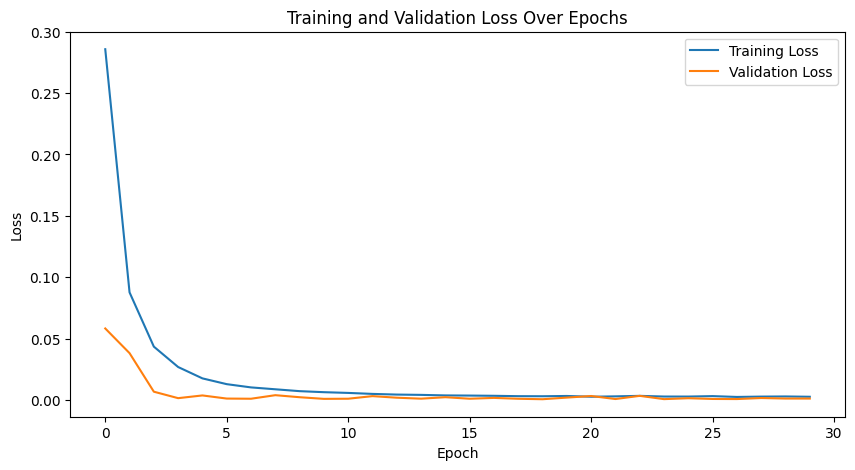

In [ ]:
# Solution
# Plotting the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**[5.2]** Let's plot the train and validation MAE(Mean Squared Error)

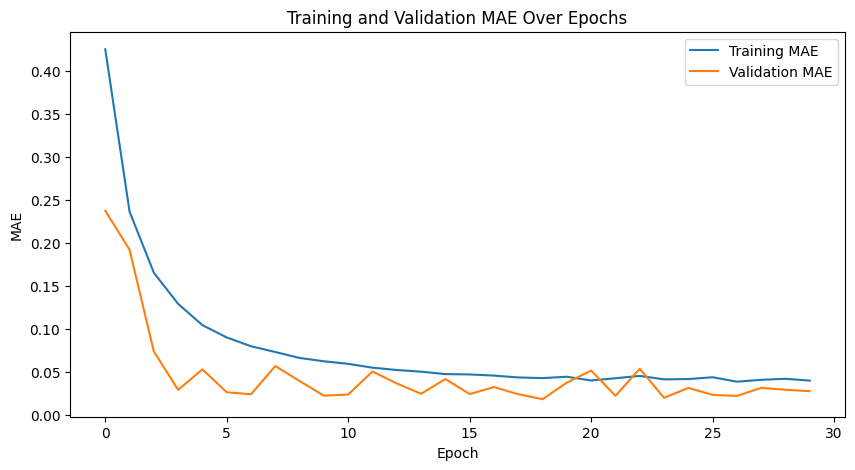

In [ ]:
# Solution
# Plotting the training and validation MAE
plt.figure(figsize=(10, 5))
plt.plot(train_maes, label='Training MAE')
plt.plot(val_maes, label='Validation MAE')
plt.title('Training and Validation MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

**[5.3]** We will now plot the train and validation RMSE(Root Mean Squared Error)

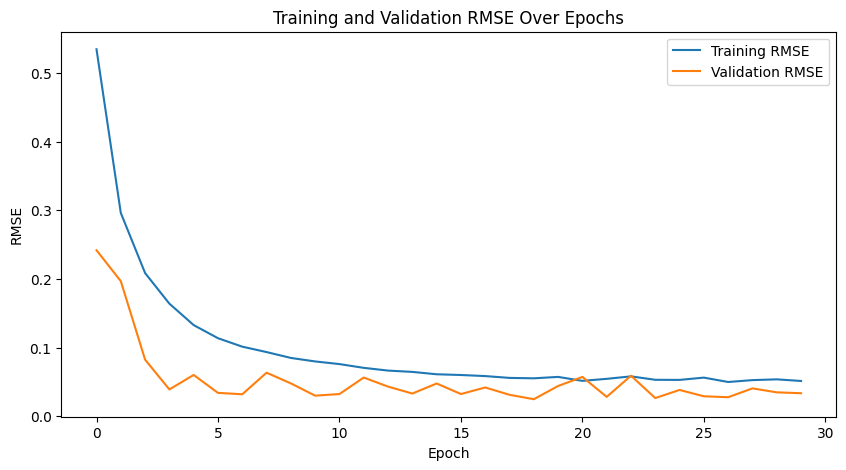

In [ ]:
# Solution
# Plotting the training and validation RMSE
plt.figure(figsize=(10, 5))
plt.plot(train_rmses, label='Training RMSE')
plt.plot(val_rmses, label='Validation RMSE')
plt.title('Training and Validation RMSE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.show()

**[5.4]** Let's set the model in evaluation mode, prepare the test data as a tensor on the correct device, and generate predictions without gradient tracking.

In [ ]:
# Solution
# Ensure the model is set to evaluation mode to disable dropout and batch normalization layers
model.eval()

# Convert the test data into a PyTorch tensor if it's not already in this format
if not isinstance(X_test, torch.Tensor):
    X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
else:
    X_test_tensor = X_test.to(device)

# Generate predictions for the test data without computing gradients for efficiency
with torch.no_grad():
    predicted_test = model(X_test_tensor).cpu().numpy()

**[5.5]** Let's convert `y_test` to a numpy array for plotting.

In [ ]:
# Solution
# Convert y_test to a numpy array if it's stored as a PyTorch tensor for easy plotting
if isinstance(y_test, torch.Tensor):
    y_test_numpy = y_test.cpu().numpy()
else:
    y_test_numpy = y_test

**[5.6]** Let's displays actual vs. predicted temparatures on test dates with matplotlib.

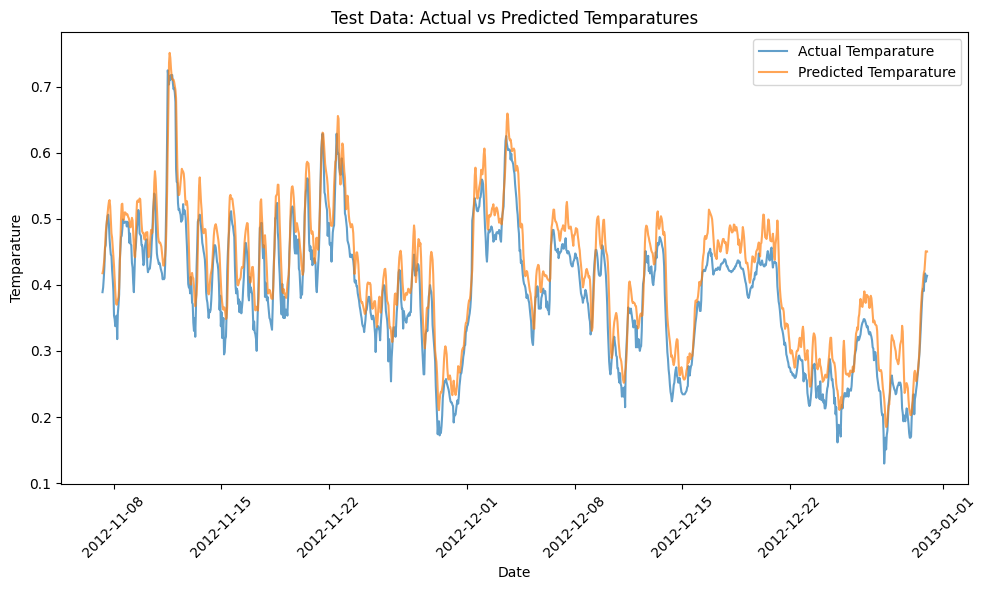

In [ ]:
# Solution
# Extract dates for plotting from the test DataFrame's index
test_dates = test_df.index[:len(predicted_test)]

# Plotting the actual and predicted 'Temparature' on the test dataset
plt.figure(figsize=(10, 6))
plt.plot(test_dates, y_test_numpy, label='Actual Temparature', alpha=0.7)
plt.plot(test_dates, predicted_test, label='Predicted Temparature', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Temparature')
plt.title('Test Data: Actual vs Predicted Temparatures')
plt.legend()
plt.xticks(rotation=45)  # Improve readability by rotating date labels
plt.tight_layout()  # Adjust the layout to accommodate the rotated labels
plt.show()